# Cálculo de derivadas mediante diferencias finitas

## Objetivo

En este notebook se estudia el cálculo numérico de derivadas usando **diferencias finitas**.  
Se incluyen varios aspectos didácticos importantes:

- aproximaciones para la **primera derivada**,
- fórmulas **centradas** y **descentradas**,
- fórmulas de **distinto orden de precisión**,
- aproximaciones para la **segunda derivada**,
- aproximaciones para la **tercera derivada**,
- comparación con derivadas exactas,
- análisis del error numérico.

## Idea general

Si una función \(f(x)\) es suficientemente suave, puede aproximarse localmente mediante series de Taylor.  
A partir de esas expansiones se obtienen fórmulas de diferencias finitas para aproximar derivadas.

En este notebook trabajaremos con la función:

$f(x)=e^x \sin x$

porque sus derivadas exactas pueden calcularse fácilmente y permiten comparar resultados.

## Derivadas exactas

Para

$f(x)=e^x \sin x$
se tiene:

$
f'(x)=e^x(\sin x+\cos x)
$

$
f''(x)=2e^x\cos x
$

$
f'''(x)=2e^x(\cos x-\sin x)
$

Usaremos estas expresiones para evaluar el error de las aproximaciones numéricas.

## 1. Importación de librerías

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Definición de la función y de sus derivadas exactas

In [42]:
def f(x):
    return np.exp(x) * np.sin(x)

def df_exacta(x):
    return np.exp(x) * (np.sin(x) + np.cos(x))

def d2f_exacta(x):
    return 2.0 * np.exp(x) * np.cos(x)

def d3f_exacta(x):
    return 2.0 * np.exp(x) * (np.cos(x) - np.sin(x))

## 3. Punto de evaluación y tamaños de paso

Tomaremos como punto de evaluación:

\[
x_0 = 1
\]

y ensayaremos varios tamaños de paso \(h\).

In [43]:
x0 = 1.0
hs = np.array([0.2, 0.1, 0.05, 0.025, 0.0125])

print("x0 =", x0)
print("h =", hs)

x0 = 1.0
h = [0.2    0.1    0.05   0.025  0.0125]


# Parte A. Primera derivada

## 4. Fórmulas descentradas de primer orden

### Diferencia hacia adelante

A partir de Taylor:

$
f(x+h)=f(x)+h f'(x)+\frac{h^2}{2}f''(x)+\cdots
$

despejando \(f'(x)\):

$
f'(x)\approx \frac{f(x+h)-f(x)}{h}
$

Esta fórmula tiene error de truncamiento de orden:

$
O(h)
$

### Diferencia hacia atrás

De manera análoga:

$
f'(x)\approx \frac{f(x)-f(x-h)}{h}
$

también con error:

$
O(h)
$

In [44]:
def d1_forward_o1(f, x, h):
    return (f(x + h) - f(x)) / h

def d1_backward_o1(f, x, h):
    return (f(x) - f(x - h)) / h

## 5. Fórmula centrada de segundo orden

Usando las expansiones de \(f(x+h)\) y \(f(x-h)\), al restarlas se obtiene:

$
f'(x)\approx \frac{f(x+h)-f(x-h)}{2h}
$

con error de truncamiento:

$
O(h^2)
$

Esta fórmula suele ser más precisa que las descentradas de primer orden.

In [45]:
def d1_center_o2(f, x, h):
    return (f(x + h) - f(x - h)) / (2.0 * h)

## 6. Fórmulas de orden superior para la primera derivada

### Diferencia hacia adelante de segundo orden

Una aproximación descentrada más precisa es:

$
f'(x)\approx \frac{-3f(x)+4f(x+h)-f(x+2h)}{2h}
$

con error:

$
O(h^2)
$

### Diferencia hacia atrás de segundo orden

$
f'(x)\approx \frac{3f(x)-4f(x-h)+f(x-2h)}{2h}
$

con error:

$
O(h^2)
$

### Diferencia centrada de cuarto orden

Una fórmula centrada muy usada es:

$
f'(x)\approx \frac{-f(x+2h)+8f(x+h)-8f(x-h)+f(x-2h)}{12h}
$

con error:

$
O(h^4)
$

In [46]:
def d1_forward_o2(f, x, h):
    return (-3.0*f(x) + 4.0*f(x+h) - f(x+2.0*h)) / (2.0*h)

def d1_backward_o2(f, x, h):
    return (3.0*f(x) - 4.0*f(x-h) + f(x-2.0*h)) / (2.0*h)

def d1_center_o4(f, x, h):
    return (-f(x+2.0*h) + 8.0*f(x+h) - 8.0*f(x-h) + f(x-2.0*h)) / (12.0*h)

## 7. Comparación numérica para la primera derivada

In [47]:
exacta_d1 = df_exacta(x0)

filas = []
for h in hs:
    a1 = d1_forward_o1(f, x0, h)
    a2 = d1_backward_o1(f, x0, h)
    a3 = d1_center_o2(f, x0, h)
    a4 = d1_forward_o2(f, x0, h)
    a5 = d1_backward_o2(f, x0, h)
    a6 = d1_center_o4(f, x0, h)

    filas.append({
        "h": h,
        "Exacta": exacta_d1,
        "Adelante O(h)": a1,
        "Error A O(h)": abs(a1 - exacta_d1),
        "Atrás O(h)": a2,
        "Error B O(h)": abs(a2 - exacta_d1),
        "Centrada O(h^2)": a3,
        "Error C O(h^2)": abs(a3 - exacta_d1),
        "Adelante O(h^2)": a4,
        "Error A O(h^2)": abs(a4 - exacta_d1),
        "Atrás O(h^2)": a5,
        "Error B O(h^2)": abs(a5 - exacta_d1),
        "Centrada O(h^4)": a6,
        "Error C O(h^4)": abs(a6 - exacta_d1),
    })

df_d1 = pd.DataFrame(filas)
df_d1

,h,Exacta,Adelante O(h),Error A O(h),Atrás O(h),Error B O(h),Centrada O(h^2),Error C O(h^2),Adelante O(h^2),Error A O(h^2),Atrás O(h^2),Error B O(h^2),Centrada O(h^4),Error C O(h^4)
0,0.2000,3.756049,4.035617,0.279568,3.454250,0.301799,3.744934,0.011116,3.799133,0.043084,3.762225,0.006176,3.756849,7.995916e-04
1,0.1000,3.756049,3.899796,0.143747,3.606820,0.149229,3.753308,0.002741,3.763974,0.007925,3.759390,0.003341,3.756099,5.005453e-05
2,0.0500,3.756049,3.828753,0.072704,3.681979,0.074070,3.755366,0.000683,3.757711,0.001661,3.757139,0.001089,3.756052,3.129634e-06
3,0.0250,3.756049,3.792590,0.036541,3.719167,0.036882,3.755879,0.000171,3.756427,0.000378,3.756355,0.000306,3.756049,1.956212e-07
4,0.0125,3.756049,3.774365,0.018315,3.737649,0.018401,3.756007,0.000043,3.756139,0.000090,3.756130,0.000081,3.756049,1.222659e-08


## 8. Visualización del error para la primera derivada

En escala log-log es más fácil apreciar cómo disminuye el error al reducir \(h\).

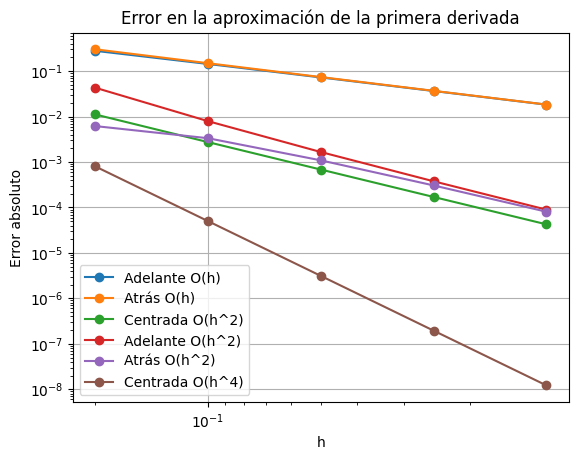

In [48]:
errores_d1 = {
    "Adelante O(h)": [],
    "Atrás O(h)": [],
    "Centrada O(h^2)": [],
    "Adelante O(h^2)": [],
    "Atrás O(h^2)": [],
    "Centrada O(h^4)": []
}

for h in hs:
    errores_d1["Adelante O(h)"].append(abs(d1_forward_o1(f, x0, h) - exacta_d1))
    errores_d1["Atrás O(h)"].append(abs(d1_backward_o1(f, x0, h) - exacta_d1))
    errores_d1["Centrada O(h^2)"].append(abs(d1_center_o2(f, x0, h) - exacta_d1))
    errores_d1["Adelante O(h^2)"].append(abs(d1_forward_o2(f, x0, h) - exacta_d1))
    errores_d1["Atrás O(h^2)"].append(abs(d1_backward_o2(f, x0, h) - exacta_d1))
    errores_d1["Centrada O(h^4)"].append(abs(d1_center_o4(f, x0, h) - exacta_d1))

for nombre, errs in errores_d1.items():
    plt.loglog(hs, errs, marker='o', label=nombre)

plt.gca().invert_xaxis()
plt.xlabel("h")
plt.ylabel("Error absoluto")
plt.title("Error en la aproximación de la primera derivada")
plt.legend()
plt.grid(True)
plt.show()

# Parte B. Segunda derivada

## 9. Fórmulas para la segunda derivada

### Fórmula centrada de segundo orden

A partir de Taylor se obtiene:

$
f''(x)\approx \frac{f(x+h)-2f(x)+f(x-h)}{h^2}
$

con error:

$
O(h^2)
$

### Fórmula centrada de cuarto orden

Una fórmula más precisa es:

$
f''(x)\approx
\frac{-f(x+2h)+16f(x+h)-30f(x)+16f(x-h)-f(x-2h)}{12h^2}
$

con error:

$
O(h^4)
$

In [49]:
def d2_center_o2(f, x, h):
    return (f(x+h) - 2.0*f(x) + f(x-h)) / (h**2)

def d2_center_o4(f, x, h):
    return (-f(x+2.0*h) + 16.0*f(x+h) - 30.0*f(x) + 16.0*f(x-h) - f(x-2.0*h)) / (12.0*h**2)

## 10. Comparación numérica para la segunda derivada

In [50]:
exacta_d2 = d2f_exacta(x0)

filas2 = []
for h in hs:
    a1 = d2_center_o2(f, x0, h)
    a2 = d2_center_o4(f, x0, h)

    filas2.append({
        "h": h,
        "Exacta": exacta_d2,
        "Centrada O(h^2)": a1,
        "Error O(h^2)": abs(a1 - exacta_d2),
        "Centrada O(h^4)": a2,
        "Error O(h^4)": abs(a2 - exacta_d2),
    })

df_d2 = pd.DataFrame(filas2)
df_d2

,h,Exacta,Centrada O(h^2),Error O(h^2),Centrada O(h^4),Error O(h^4)
0,0.2000,2.937388,2.906838,0.030550,2.937594,2.065517e-04
1,0.1000,2.937388,2.929760,0.007628,2.937401,1.301873e-05
2,0.0500,2.937388,2.935482,0.001906,2.937389,8.153734e-07
3,0.0250,2.937388,2.936911,0.000477,2.937388,5.098561e-08
4,0.0125,2.937388,2.937269,0.000119,2.937388,3.190298e-09


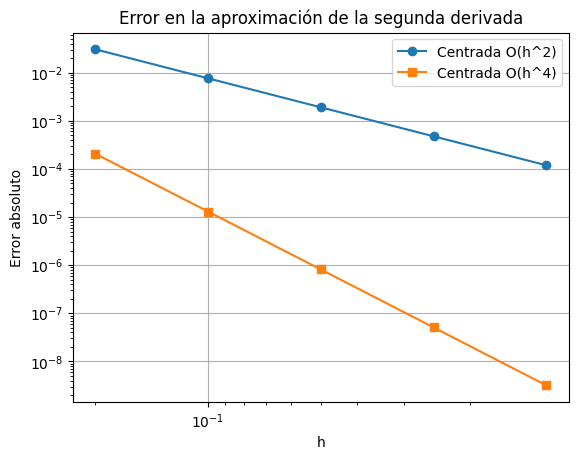

In [51]:
err_d2_o2 = [abs(d2_center_o2(f, x0, h) - exacta_d2) for h in hs]
err_d2_o4 = [abs(d2_center_o4(f, x0, h) - exacta_d2) for h in hs]

plt.loglog(hs, err_d2_o2, marker='o', label='Centrada O(h^2)')
plt.loglog(hs, err_d2_o4, marker='s', label='Centrada O(h^4)')
plt.gca().invert_xaxis()
plt.xlabel("h")
plt.ylabel("Error absoluto")
plt.title("Error en la aproximación de la segunda derivada")
plt.legend()
plt.grid(True)
plt.show()

# Parte C. Tercera derivada

## 11. Fórmula centrada para la tercera derivada

Una fórmula centrada común para la tercera derivada es:

$
f^{(3)}(x)\approx
\frac{f(x+2h)-2f(x+h)+2f(x-h)-f(x-2h)}{2h^3}
$

Esta aproximación tiene error:

$
O(h^2)
$

Nótese que para derivadas de orden superior, las fórmulas usan más puntos de la malla y son más sensibles a errores numéricos cuando \(h\) es demasiado pequeño.

In [52]:
def d3_center_o2(f, x, h):
    return (f(x+2.0*h) - 2.0*f(x+h) + 2.0*f(x-h) - f(x-2.0*h)) / (2.0*h**3)

## 12. Comparación numérica para la tercera derivada

In [53]:
exacta_d3 = d3f_exacta(x0)

filas3 = []
for h in hs:
    a1 = d3_center_o2(f, x0, h)
    filas3.append({
        "h": h,
        "Exacta": exacta_d3,
        "Centrada O(h^2)": a1,
        "Error absoluto": abs(a1 - exacta_d3)
    })

df_d3 = pd.DataFrame(filas3)
df_d3

,h,Exacta,Centrada O(h^2),Error absoluto
0,0.2000,-1.637323,-1.787297,0.149975
1,0.1000,-1.637323,-1.674867,0.037544
2,0.0500,-1.637323,-1.646712,0.009389
3,0.0250,-1.637323,-1.639670,0.002347
4,0.0125,-1.637323,-1.637910,0.000587


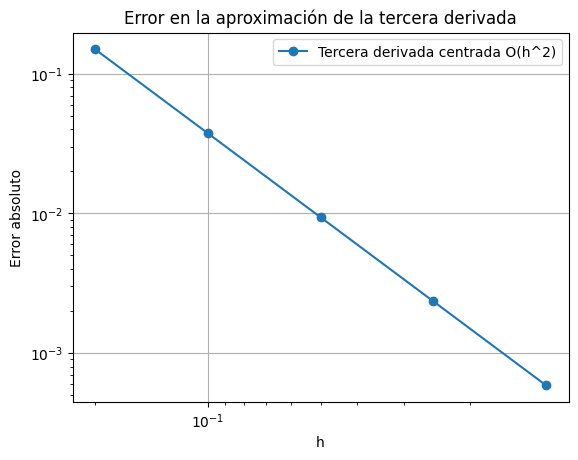

In [54]:
err_d3_o2 = [abs(d3_center_o2(f, x0, h) - exacta_d3) for h in hs]

plt.loglog(hs, err_d3_o2, marker='o', label='Tercera derivada centrada O(h^2)')
plt.gca().invert_xaxis()
plt.xlabel("h")
plt.ylabel("Error absoluto")
plt.title("Error en la aproximación de la tercera derivada")
plt.legend()
plt.grid(True)
plt.show()

# Parte D. Ejemplo sobre una malla completa

## 13. Aproximación de derivadas en varios nodos

Hasta ahora hemos aproximado derivadas en un solo punto \(x_0\).  
Ahora mostraremos cómo aproximar la primera y la segunda derivada sobre una malla uniforme.

Tomaremos el intervalo:

$
0 \le x \le 2
$

con $N=21$ nodos.

In [55]:
a, b = 0.0, 2.0
N = 21
x = np.linspace(a, b, N)
h = x[1] - x[0]
y = f(x)

print("Paso h =", h)

Paso h = 0.1


## 14. Primera derivada en una malla

Usaremos:

- diferencia hacia adelante en el extremo izquierdo,
- diferencia hacia atrás en el extremo derecho,
- diferencia centrada en los nodos interiores.

In [56]:
d1_num = np.zeros_like(y)

# Extremo izquierdo
d1_num[0] = (-3*y[0] + 4*y[1] - y[2]) / (2*h)

# Nodos interiores
for i in range(1, N-1):
    d1_num[i] = (y[i+1] - y[i-1]) / (2*h)

# Extremo derecho
d1_num[-1] = (3*y[-1] - 4*y[-2] + y[-3]) / (2*h)

d1_ex = df_exacta(x)
error_d1_malla = np.abs(d1_num - d1_ex)

tabla_malla_d1 = pd.DataFrame({
    "x": x,
    "f(x)": y,
    "f'(x) exacta": d1_ex,
    "f'(x) numérica": d1_num,
    "Error abs": error_d1_malla
})

tabla_malla_d1.head(10)

,x,f(x),f'(x) exacta,f'(x) numérica,Error abs
0,0.0,0.000000,1.000000,0.993383,0.006617
1,0.1,0.110333,1.209983,1.213276,0.003294
2,0.2,0.242655,1.439711,1.442888,0.003177
3,0.3,0.398911,1.688480,1.691443,0.002963
4,0.4,0.580944,1.955005,1.957643,0.002637
5,0.5,0.790439,2.237328,2.239509,0.002181
6,0.6,1.028846,2.532705,2.534280,0.001575
7,0.7,1.297295,2.837498,2.838298,0.000800
8,0.8,1.596505,3.147055,3.146891,0.000164
9,0.9,1.926673,3.455587,3.454250,0.001337


## 15. Segunda derivada en una malla

En los nodos interiores se usa la fórmula centrada:

$
f''(x_i)\approx \frac{f_{i+1}-2f_i+f_{i-1}}{h^2}
$

Para simplificar la presentación, aquí calcularemos la segunda derivada solo en nodos interiores.

In [57]:
d2_num = np.full_like(y, np.nan)

for i in range(1, N-1):
    d2_num[i] = (y[i+1] - 2*y[i] + y[i-1]) / h**2

d2_ex = d2f_exacta(x)
error_d2_malla = np.abs(d2_num - d2_ex)

tabla_malla_d2 = pd.DataFrame({
    "x": x,
    "f''(x) exacta": d2_ex,
    "f''(x) numérica": d2_num,
    "Error abs": error_d2_malla
})

tabla_malla_d2.head(10)

,x,f''(x) exacta,f''(x) numérica,Error abs
0,0.0,2.000000,NaN,NaN
1,0.1,2.199299,2.198929,0.000370
2,0.2,2.394112,2.393301,0.000812
3,0.3,2.579139,2.577806,0.001333
4,0.4,2.748123,2.746184,0.001940
5,0.5,2.893778,2.891140,0.002638
6,0.6,3.007719,3.004286,0.003433
7,0.7,3.080406,3.076078,0.004328
8,0.8,3.101099,3.095773,0.005325
9,0.9,3.057828,3.051402,0.006426


## 16. Gráficas comparativas en la malla

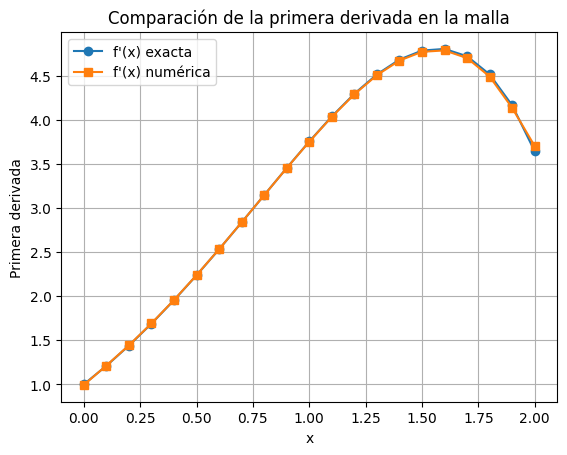

In [58]:
plt.plot(x, d1_ex, marker='o', label="f'(x) exacta")
plt.plot(x, d1_num, marker='s', label="f'(x) numérica")
plt.xlabel("x")
plt.ylabel("Primera derivada")
plt.title("Comparación de la primera derivada en la malla")
plt.legend()
plt.grid(True)
plt.show()

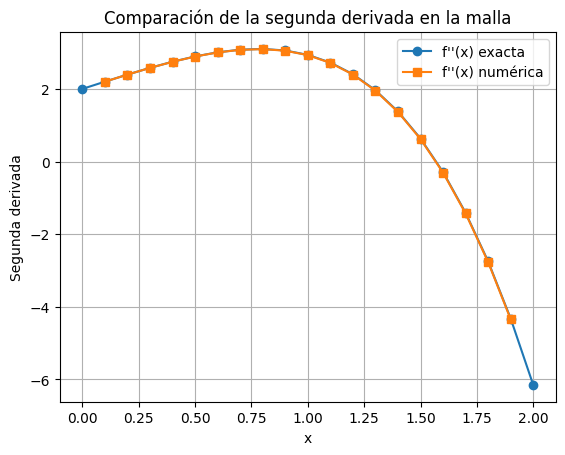

In [59]:
plt.plot(x, d2_ex, marker='o', label="f''(x) exacta")
plt.plot(x, d2_num, marker='s', label="f''(x) numérica")
plt.xlabel("x")
plt.ylabel("Segunda derivada")
plt.title("Comparación de la segunda derivada en la malla")
plt.legend()
plt.grid(True)
plt.show()

# Parte E. Conclusiones didácticas

## 17. Ideas clave

1. Las fórmulas **descentradas** son útiles cerca de fronteras, donde no siempre se dispone de puntos a ambos lados.

2. Las fórmulas **centradas** suelen ser más precisas porque cancelan términos impares de la expansión de Taylor.

3. El **orden de precisión** importa:
   - una fórmula \(O(h)\) mejora linealmente al disminuir \(h\),
   - una fórmula \(O(h^2)\) mejora más rápido,
   - una fórmula \(O(h^4)\) puede ser mucho más precisa si la función es suave.

4. Para derivadas de orden alto, la precisión puede deteriorarse si \(h\) es demasiado pequeño debido a redondeo numérico.

5. En mallas reales de problemas de ingeniería, es común usar:
   - fórmulas centradas en el interior,
   - fórmulas descentradas en los extremos.

## 18. Ejercicios sugeridos

1. Repetir todo el análisis para la función:

\[
f(x)=\ln(1+x)
\]

2. Cambiar el punto \(x_0\) y estudiar cómo cambian los errores.

3. Construir una tabla de orden experimental de convergencia:

\[
p \approx \frac{\ln(E_h/E_{h/2})}{\ln 2}
\]

4. Implementar una fórmula descentrada para la segunda derivada en un extremo del dominio.

In [60]:
# Cálculo opcional del orden experimental de convergencia para algunas fórmulas

def orden_experimental(errores):
    ordenes = []
    for i in range(len(errores) - 1):
        ordenes.append(np.log(errores[i] / errores[i+1]) / np.log(2.0))
    return ordenes

print("Orden experimental para d/dx centrada O(h^2):")
print(orden_experimental(errores_d1["Centrada O(h^2)"]))

print("\nOrden experimental para d/dx centrada O(h^4):")
print(orden_experimental(errores_d1["Centrada O(h^4)"]))

print("\nOrden experimental para d2/dx2 centrada O(h^2):")
print(orden_experimental(err_d2_o2))

print("\nOrden experimental para d2/dx2 centrada O(h^4):")
print(orden_experimental(err_d2_o4))

Orden experimental para d/dx centrada O(h^2):
[2.019622373433353, 2.004949522894421, 2.001240159357876, 2.0003102135711917]

Orden experimental para d/dx centrada O(h^4):
[3.9976908271560685, 3.9994345467560075, 3.9998594983777385, 3.999968473921449]

Orden experimental para d2/dx2 centrada O(h^2):
[2.0018455610664248, 2.0004627259819077, 2.0001157625308204, 2.0000289838705343]

Orden experimental para d2/dx2 centrada O(h^4):
[3.987842525707601, 3.9969837727800175, 3.9992990252972964, 3.998326814565074]
